## Methodology

### Training and Iterate Collection

A ResNet-20 (~272k parameters) is trained on 15,000 CIFAR-10 samples using SGD ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, cosine annealing, 15 epochs). The full parameter vector is stored in float16 after every mini-batch update, yielding $T = 1{,}770$ iterates.

### Baseline Processes

Two stochastic baseline trajectories are simulated in the full parameter space $\mathbb{R}^{272474}$, each with the same number of steps $T$ and starting point $\theta_0$ as the SGD trajectory.

**Isotropic random walk:**
$$\theta_{t+1} = \theta_t + \sigma\,\xi_t, \quad \xi_t \sim \mathcal{N}(0, I)$$

**Ornstein–Uhlenbeck process** with attractor $\theta^* = \theta_T$:
$$\theta_{t+1} = \theta_t - \mu\,(\theta_t - \theta^*) + \sigma\,\xi_t$$

The diffusion coefficient $\sigma$ is calibrated to match the mean per-step norm of the SGD trajectory: $\hat\sigma = \overline{\|\Delta\theta_t\|_2} / \sqrt{D}$. The restoring strength $\mu$ controls how strongly the process is attracted towards the final SGD iterate; $\mu = 0$ recovers the random walk, and $\mu \to 1$ produces near-linear drift towards $\theta^*$.

### Windowed PCA

PCA is applied in a sliding window of 250 iterates (stride 30) over each of the three trajectories (SGD, RW, OU). The top-$k$ explained variance ratios are computed per window, tracking how the local spectral shape of each process evolves over time. The PC1 share of the OU process is compared to that of SGD and the isotropic random walk to assess which model better reproduces the time-varying dimensionality of the SGD trajectory.

### Phase-wise PCA

Each trajectory is divided into $N=5$ equally sized, non-overlapping phases. PCA is fitted independently per phase and the top-5 explained variance ratios are extracted and compared to the theoretical random-walk spectrum $\lambda_k \propto 6/(\pi^2 k^2)$. Comparing phase spectra between SGD and the OU process quantifies how well the OU model reproduces the phase-dependent transition from directional early-training dynamics to the more diffuse late-training regime.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.2.2


In [2]:
# ── Seed ─────────────────────────────────────────────────────
SEED = 123

# ── Training ─────────────────────────────────────────────────
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
EPOCHS       = 15
BATCH_SIZE   = 128
TRAIN_SIZE   = 15000
TEST_SIZE    = 5000

# ── OU Grid: verschiedene mu-Werte zum Vergleichen ───────────
# Für den Screeplot kannst du einen dieser Werte als OU_SHOW wählen
OU_MU_LIST = [0.001]
OU_SHOW    = 0.001   # dieser OU wird in den Screeplots angezeigt

# ── Fensterweise PCA ─────────────────────────────────────────
WINDOW_SIZE   = 250
WINDOW_STRIDE = 30

# ── Phasen ───────────────────────────────────────────────────
N_PHASES    = 5

# ── PCA ──────────────────────────────────────────────────────
N_COMPONENTS = 5

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Seed: {SEED}")

Seed: 123


In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True,
    transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=transform_test)

if TRAIN_SIZE is not None:
    full_train = torch.utils.data.Subset(
        full_train,
        torch.randperm(len(full_train))[:TRAIN_SIZE].tolist())
if TEST_SIZE is not None:
    full_test = torch.utils.data.Subset(
        full_test,
        torch.randperm(len(full_test))[:TEST_SIZE].tolist())

trainloader = torch.utils.data.DataLoader(
    full_train, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0)
testloader  = torch.utils.data.DataLoader(
    full_test, batch_size=256,
    shuffle=False, num_workers=0)

print(f"Train-Batches: {len(trainloader)} | "
      f"Test-Batches: {len(testloader)}")

Files already downloaded and verified
Files already downloaded and verified
Train-Batches: 118 | Test-Batches: 20


In [5]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3,
                                  stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3,
                                  stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1,
                                  padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(16, 16, 3, stride=1)
        self.layer2  = self._make_layer(16, 32, 3, stride=2)
        self.layer3  = self._make_layer(32, 64, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))


model    = ResNet20().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
D_RESNET = n_params
print(f"ResNet20: {n_params:,} Parameter  |  "
      f"RAM/Iterate (f16): {n_params*2/1e6:.2f} MB")

ResNet20: 272,474 Parameter  |  RAM/Iterate (f16): 0.54 MB


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS)

train_losses, train_accs, test_accs = [], [], []
iterates = []

def get_snap(m):
    return np.concatenate([
        p.detach().cpu().numpy().ravel()
        for p in m.parameters()
    ]).astype(np.float16)


for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()

        iterates.append(get_snap(model))

        running_loss += loss.item() * inputs.size(0)
        with torch.no_grad():
            correct += (model(inputs).max(1)[1]
                        .eq(labels).sum().item())
        total += labels.size(0)

    tl  = running_loss / total
    ta  = 100. * correct / total
    model.eval()
    c2, t2 = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            c2 += (model(inputs).max(1)[1]
                   .eq(labels).sum().item())
            t2 += labels.size(0)
    tea = 100. * c2 / t2

    train_losses.append(tl)
    train_accs.append(ta)
    test_accs.append(tea)
    scheduler.step()
    print(f"Epoch {epoch:3d}/{EPOCHS}  Loss={tl:.4f}  "
          f"Train={ta:.1f}%  Test={tea:.1f}%  "
          f"Iterates: {len(iterates)}")

iterates        = np.stack(iterates).astype(np.float32)
T_total         = len(iterates)
steps_per_epoch = T_total // EPOCHS

theta_0 = iterates[0].copy()
theta_T = iterates[-1].copy()

print(f"\nIterates gesamt: {iterates.shape}  |  "
      f"RAM: {iterates.nbytes/1e6:.1f} MB")

Epoch   1/15  Loss=1.9385  Train=29.2%  Test=30.6%  Iterates: 118
Epoch   2/15  Loss=1.6934  Train=38.2%  Test=37.3%  Iterates: 236
Epoch   3/15  Loss=1.5224  Train=45.5%  Test=44.8%  Iterates: 354
Epoch   4/15  Loss=1.3988  Train=50.8%  Test=50.5%  Iterates: 472
Epoch   5/15  Loss=1.2660  Train=56.0%  Test=54.9%  Iterates: 590
Epoch   6/15  Loss=1.1535  Train=60.8%  Test=52.4%  Iterates: 708
Epoch   7/15  Loss=1.0543  Train=64.2%  Test=60.7%  Iterates: 826
Epoch   8/15  Loss=0.9747  Train=67.4%  Test=64.1%  Iterates: 944
Epoch   9/15  Loss=0.9000  Train=69.5%  Test=67.2%  Iterates: 1062
Epoch  10/15  Loss=0.8381  Train=71.4%  Test=68.9%  Iterates: 1180
Epoch  11/15  Loss=0.7834  Train=73.0%  Test=69.8%  Iterates: 1298
Epoch  12/15  Loss=0.7349  Train=74.6%  Test=71.8%  Iterates: 1416
Epoch  13/15  Loss=0.6927  Train=75.7%  Test=72.2%  Iterates: 1534
Epoch  14/15  Loss=0.6597  Train=76.5%  Test=73.6%  Iterates: 1652
Epoch  15/15  Loss=0.6363  Train=77.4%  Test=73.9%  Iterates: 1770

It

In [7]:
def simulate_random_walk(D, T, sigma, theta_0):
    """
    theta_{t+1} = theta_t + sigma * xi_t,   xi_t ~ N(0, I_D)
    """
    its    = np.zeros((T + 1, D), dtype=np.float32)
    its[0] = theta_0.copy()
    theta  = theta_0.copy()
    for t in range(T):
        xi       = (sigma * np.random.randn(D)).astype(np.float32)
        theta    = theta + xi
        its[t+1] = theta
    return its


def simulate_ou(D, T, mu, sigma, theta_0, theta_star):
    """
    theta_{t+1} = theta_t - mu*(theta_t - theta_star) + sigma*xi_t

    theta_0:    Startpunkt  = SGD-Startpunkt
    theta_star: Gleichgewicht = SGD-Endpunkt
    mu:         Rückstellkraft in (0, 2)
    sigma:      wie Random Walk kalibriert
    """
    assert 0 < mu < 2, f"mu={mu} muss in (0, 2) liegen"
    its    = np.zeros((T + 1, D), dtype=np.float32)
    its[0] = theta_0.copy()
    theta  = theta_0.copy()
    for t in range(T):
        drift    = -mu * (theta - theta_star)
        noise    = (sigma * np.random.randn(D)).astype(np.float32)
        theta    = theta + drift + noise
        its[t+1] = theta
    return its


# ── Kalibrierung sigma ────────────────────────────────────────
sgd_steps     = np.diff(iterates, axis=0)
mean_sgd_norm = float(np.linalg.norm(sgd_steps, axis=1).mean())
sigma_cal     = mean_sgd_norm / np.sqrt(D_RESNET)

T_SIM     = T_total - 1
iters_sim = np.arange(T_total, dtype=np.int64)

print(f"sigma_kalibriert = {sigma_cal:.8f}")
print(f"T_SIM = {T_SIM}")

# ── Random Walk ───────────────────────────────────────────────
print("\nSimuliere Random Walk...")
iterates_rw = simulate_random_walk(
    D_RESNET, T_SIM, sigma_cal, theta_0)

# ── OU für jeden mu-Wert im Array ────────────────────────────
iterates_ou_dict = {}
for mu in OU_MU_LIST:
    print(f"Simuliere OU (mu={mu})...")
    iterates_ou_dict[mu] = simulate_ou(
        D_RESNET, T_SIM, mu, sigma_cal,
        theta_0=theta_0, theta_star=theta_T)

print("\nFertig. Simulierte Prozesse:")
print(f"  Random Walk:   {iterates_rw.shape}")
for mu, its in iterates_ou_dict.items():
    print(f"  OU (mu={mu}): {its.shape}")

sigma_kalibriert = 0.00022431
T_SIM = 1769

Simuliere Random Walk...
Simuliere OU (mu=0.001)...

Fertig. Simulierte Prozesse:
  Random Walk:   (1770, 272474)
  OU (mu=0.001): (1770, 272474)


In [8]:
def compute_spectrum(data, n_components):
    """Zentrierte PCA, gibt erklärte Varianz zurück."""
    nc     = min(n_components, len(data)-1, data.shape[1]-1)
    data_c = data - data.mean(axis=0)
    pca    = PCA(n_components=nc)
    pca.fit(data_c)
    ev = pca.explained_variance_ratio_
    if len(ev) < n_components:
        ev = np.concatenate([ev, np.zeros(n_components - len(ev))])
    return ev[:n_components]


def rolling_spectrum(data, iters, window_size, stride, n_components):
    """Rollende PCA — gibt (centers, spectra) zurück."""
    T      = len(data)
    starts = range(0, T - window_size + 1, stride)
    centers, spectra = [], []
    for s in starts:
        e = s + window_size
        centers.append(float(iters[s + window_size // 2]))
        spectra.append(compute_spectrum(data[s:e], n_components))
    return np.array(centers), np.array(spectra)


def phase_spectrum(data, n_phases, n_components):
    """PCA pro Phase (gleich groß), gibt Liste von Spektren zurück."""
    T      = len(data)
    bounds = np.linspace(0, T, n_phases + 1, dtype=int)
    specs  = []
    for i in range(n_phases):
        s, e = bounds[i], bounds[i+1]
        specs.append(compute_spectrum(data[s:e], n_components))
    return specs

In [9]:
print("Berechne rollende PCA...")

c_sgd, s_sgd = rolling_spectrum(
    iterates, np.arange(T_total),
    WINDOW_SIZE, WINDOW_STRIDE, N_COMPONENTS)

c_rw, s_rw = rolling_spectrum(
    iterates_rw, iters_sim,
    WINDOW_SIZE, WINDOW_STRIDE, N_COMPONENTS)

roll_ou = {}
for mu, its_ou in iterates_ou_dict.items():
    c_ou, s_ou = rolling_spectrum(
        its_ou, iters_sim,
        WINDOW_SIZE, WINDOW_STRIDE, N_COMPONENTS)
    roll_ou[mu] = (c_ou, s_ou)
    print(f"  OU (mu={mu}): {len(c_ou)} Fenster")

print(f"  SGD:          {len(c_sgd)} Fenster")
print(f"  Random Walk:  {len(c_rw)} Fenster")

Berechne rollende PCA...
  OU (mu=0.001): 51 Fenster
  SGD:          51 Fenster
  Random Walk:  51 Fenster


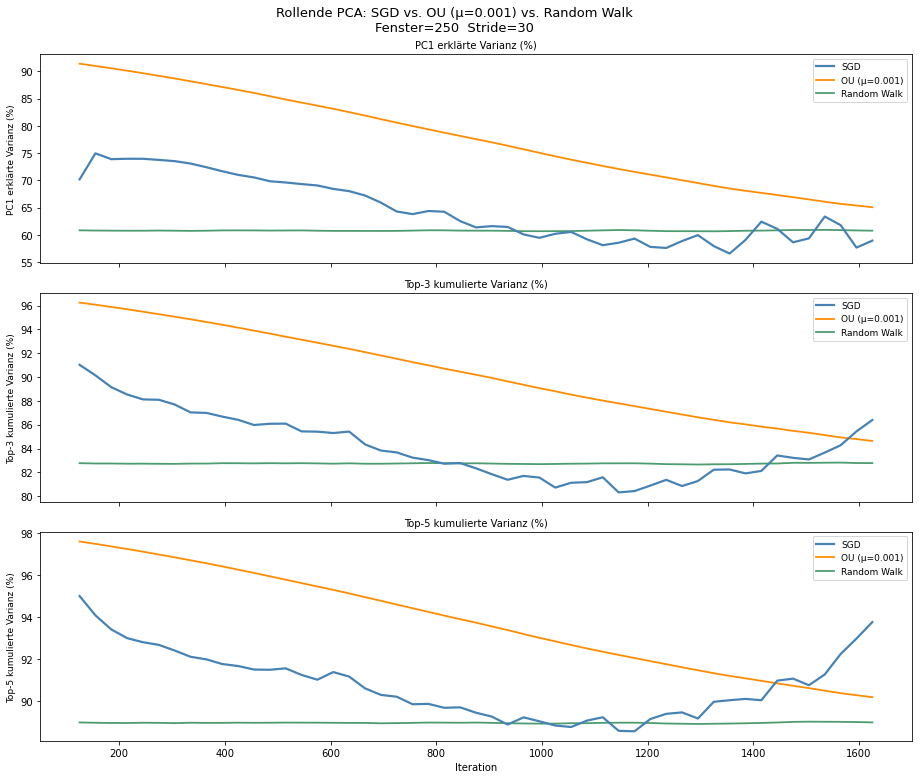

In [10]:
# OU_SHOW auf SGD-Zeitpunkte interpolieren
def interp_spec(c_src, s_src, c_tgt, n_comp):
    out = np.zeros((len(c_tgt), n_comp))
    for k in range(n_comp):
        out[:, k] = np.interp(c_tgt, c_src, s_src[:, k])
    return out


c_ou_show, s_ou_show = roll_ou[OU_SHOW]
s_ou_i = interp_spec(c_ou_show, s_ou_show, c_sgd, N_COMPONENTS)
s_rw_i = interp_spec(c_rw,      s_rw,      c_sgd, N_COMPONENTS)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle(
    f"Rollende PCA: SGD vs. OU (μ={OU_SHOW}) vs. Random Walk\n"
    f"Fenster={WINDOW_SIZE}  Stride={WINDOW_STRIDE}",
    fontsize=13)

configs = [
    ("PC1 erklärte Varianz (%)",     [0]),
    ("Top-3 kumulierte Varianz (%)", [0, 1, 2]),
    ("Top-5 kumulierte Varianz (%)", [0, 1, 2, 3, 4]),
]

for ax, (title, idx) in zip(axes, configs):
    ax.plot(c_sgd, s_sgd[:, idx].sum(axis=1) * 100,
            lw=2.2, color='steelblue',
            label='SGD', zorder=3)
    ax.plot(c_sgd, s_ou_i[:, idx].sum(axis=1) * 100,
            lw=1.8, color='darkorange',
            label=f'OU (μ={OU_SHOW})', zorder=2)
    ax.plot(c_sgd, s_rw_i[:, idx].sum(axis=1) * 100,
            lw=1.8, color='seagreen',
            label='Random Walk', alpha=0.85, zorder=1)
    ax.set_ylabel(title, fontsize=9)
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=10)

axes[-1].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

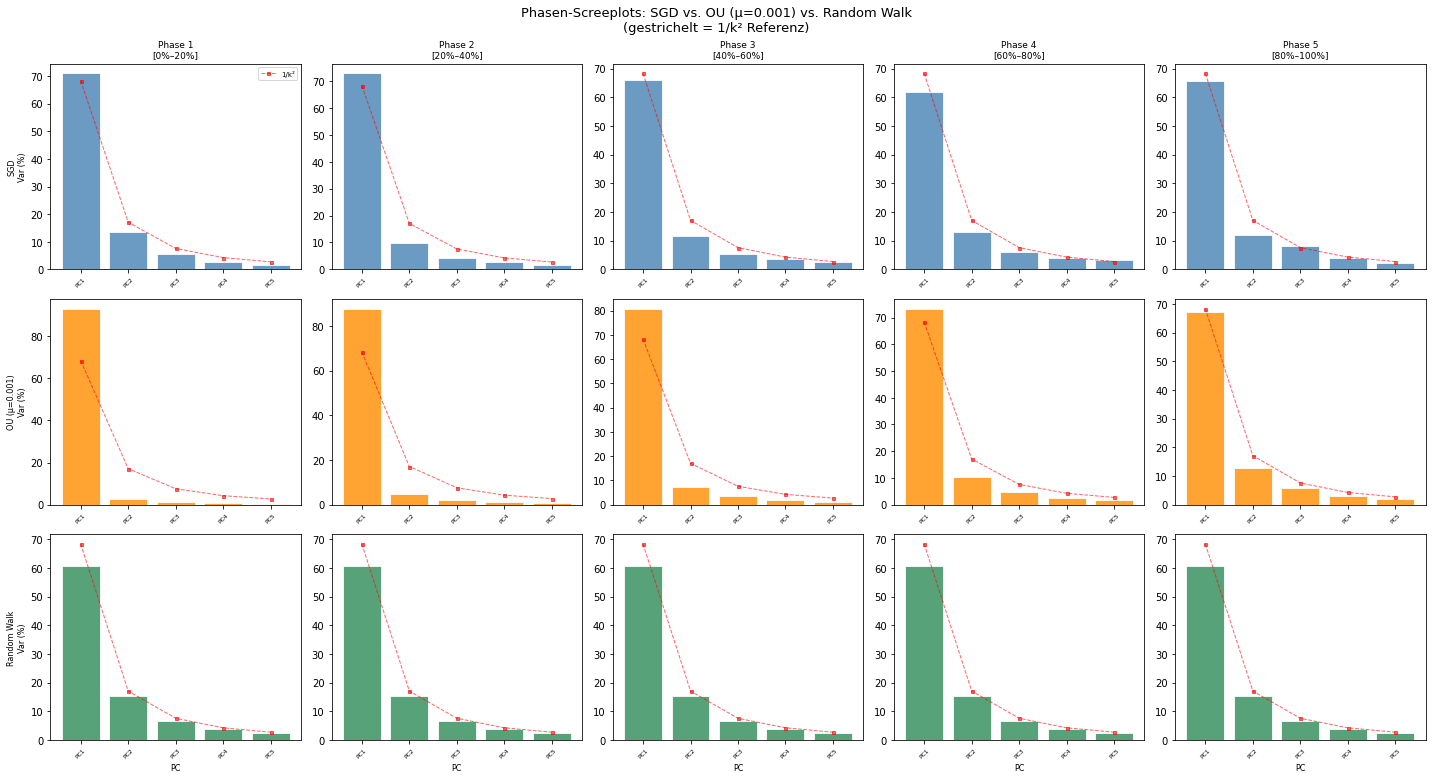

In [11]:
# Phasen-Spektren berechnen
phase_sgd = phase_spectrum(iterates,    N_PHASES, N_COMPONENTS)
phase_rw  = phase_spectrum(iterates_rw, N_PHASES, N_COMPONENTS)
phase_ou  = phase_spectrum(
    iterates_ou_dict[OU_SHOW], N_PHASES, N_COMPONENTS)

T          = T_total
bounds     = np.linspace(0, T, N_PHASES + 1, dtype=int)
pc_labels  = [f"PC{k+1}" for k in range(N_COMPONENTS)]
x          = np.arange(N_COMPONENTS)
w          = 0.25

# 1/k² Referenz
k_ref   = np.arange(1, N_COMPONENTS + 1)
ref_raw = 6.0 / (np.pi**2 * k_ref**2)
ref_raw = ref_raw / ref_raw.sum()

fig, axes = plt.subplots(3, N_PHASES,
                          figsize=(4 * N_PHASES, 11))
fig.suptitle(
    f"Phasen-Screeplots: SGD vs. OU (μ={OU_SHOW}) vs. Random Walk\n"
    f"(gestrichelt = 1/k² Referenz)",
    fontsize=13)

row_labels = ['SGD', f'OU (μ={OU_SHOW})', 'Random Walk']
row_colors = ['steelblue', 'darkorange', 'seagreen']
all_phases = [phase_sgd, phase_ou, phase_rw]

for row, (specs, lbl, col) in enumerate(
        zip(all_phases, row_labels, row_colors)):

    for ph in range(N_PHASES):
        ax  = axes[row, ph]
        ev  = specs[ph]
        pct_s = bounds[ph] / T
        pct_e = bounds[ph+1] / T

        ax.bar(x, ev * 100, color=col,
               alpha=0.80, edgecolor='white')
        ax.plot(x, ref_raw * 100, 's--',
                color='red', ms=3, lw=1,
                alpha=0.6, label='1/k²')

        if row == 0:
            ax.set_title(
                f"Phase {ph+1}\n"
                f"[{pct_s:.0%}–{pct_e:.0%}]",
                fontsize=9)
        if ph == 0:
            ax.set_ylabel(f"{lbl}\nVar (%)", fontsize=8)
        if row == 2:
            ax.set_xlabel("PC", fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(pc_labels, fontsize=6,
                           rotation=45)
        if ph == 0 and row == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

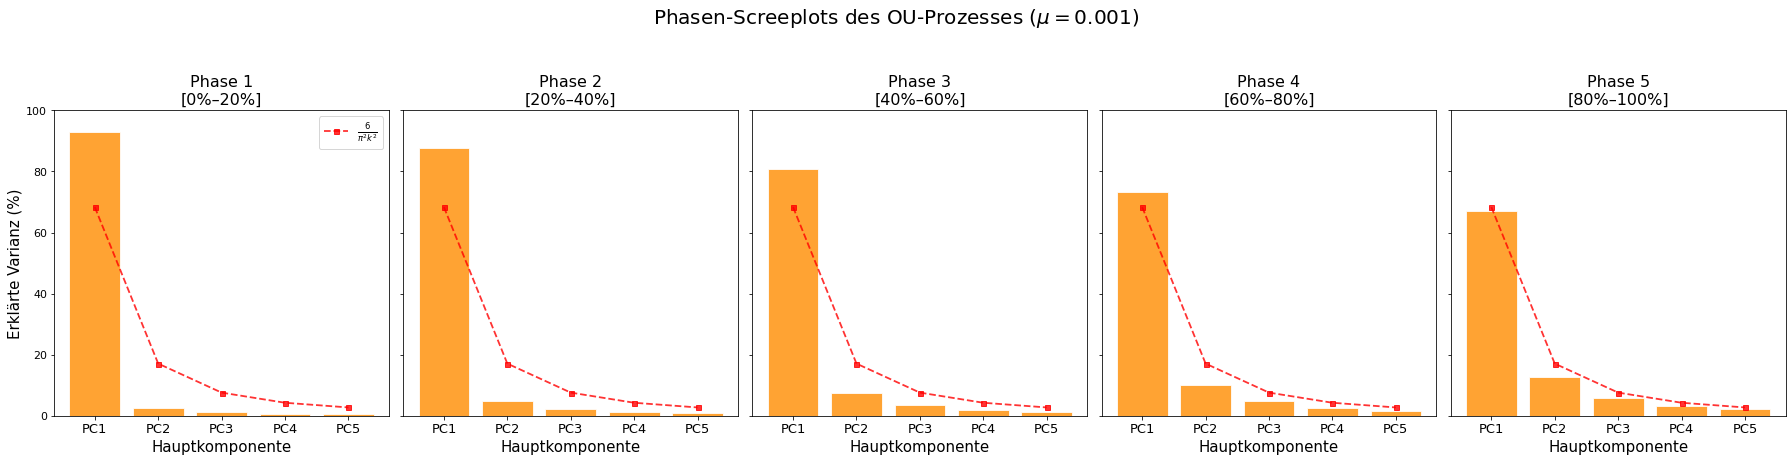

In [12]:
# Phasen-Spektrum nur für OU berechnen
phase_ou = phase_spectrum(
    iterates_ou_dict[OU_SHOW], N_PHASES, N_COMPONENTS
)

T = T_total
bounds = np.linspace(0, T, N_PHASES + 1, dtype=int)

pc_labels = [f"PC{k+1}" for k in range(N_COMPONENTS)]
x = np.arange(N_COMPONENTS)

# Referenz: 6/(π²k²)
k_ref = np.arange(1, N_COMPONENTS + 1)
ref_raw = 6.0 / (np.pi**2 * k_ref**2)
ref_raw = ref_raw / ref_raw.sum()

fig, axes = plt.subplots(
    1, N_PHASES,
    figsize=(5 * N_PHASES, 6.5),   # höher und breiter
    sharey=True
)

fig.suptitle(
    f"Phasen-Screeplots des OU-Prozesses ($\\mu={OU_SHOW}$)",
    fontsize=20
)

# Falls nur eine Phase existiert
if N_PHASES == 1:
    axes = [axes]

for ph in range(N_PHASES):
    ax = axes[ph]

    ev = phase_ou[ph]
    pct_s = bounds[ph] / T
    pct_e = bounds[ph + 1] / T

    # Balken
    ax.bar(
        x,
        ev * 100,
        color="darkorange",
        alpha=0.8,
        edgecolor="white"
    )

    # 6/(π²k²)-Referenz
    ax.plot(
        x,
        ref_raw * 100,
        "s--",
        color="red",
        ms=5,
        lw=1.8,
        alpha=0.8,
        label=r"$\frac{6}{\pi^2 k^2}$"
    )

    ax.set_title(
        f"Phase {ph+1}\n[{pct_s:.0%}–{pct_e:.0%}]",
        fontsize=16
    )

    ax.set_xlabel("Hauptkomponente", fontsize=15)

    if ph == 0:
        ax.set_ylabel("Erklärte Varianz (%)", fontsize=15)
        ax.legend(fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(pc_labels, fontsize=13)

    # Einheitliche y-Skala
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()